🔍 تست نمایش متن فارسی با روش‌های مختلف

🚀 شروع تست‌ها...


📝 متن: 'سلام دنیا'
------------------------------------------------------------


/tmp/ipykernel_313716/3411126589.py:176: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from current font.
  plt.tight_layout()
/root/miniconda3/envs/ilarima/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


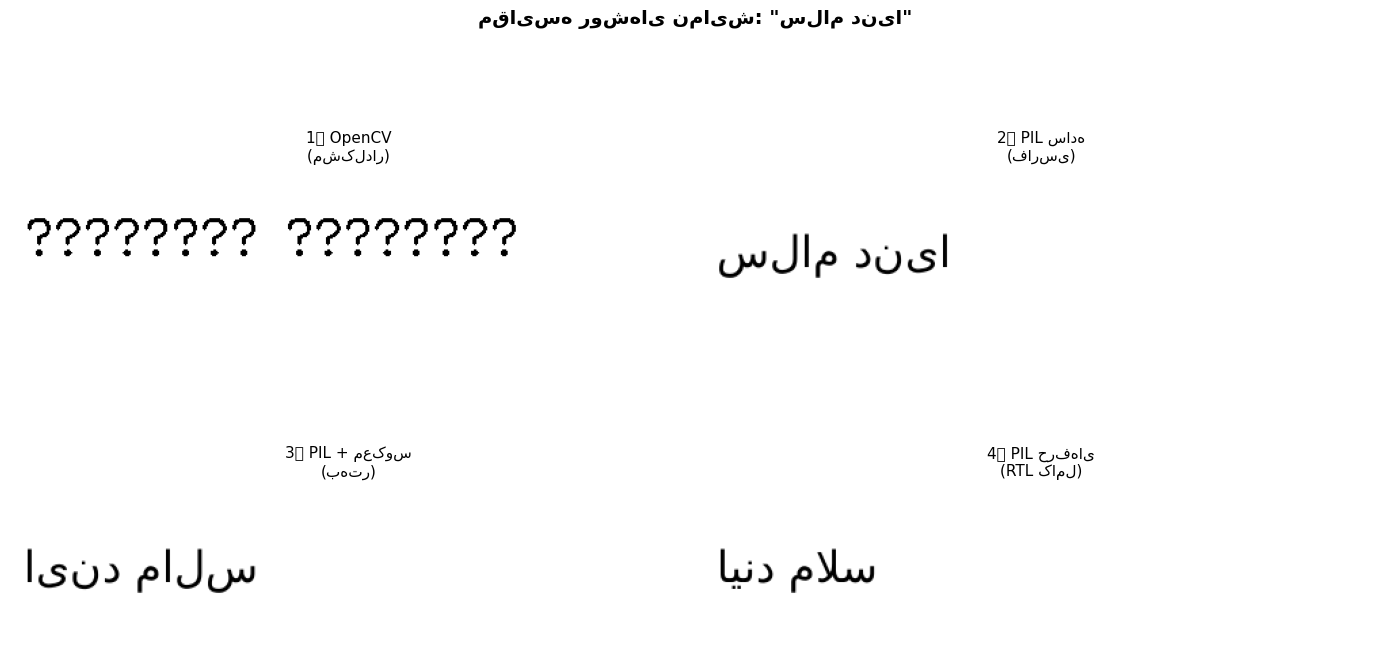


🔍 تحلیل:
  • 1️⃣ OpenCV (مشکل‌دار)              :   2120 پیکسل متن
  • 2️⃣ PIL ساده (فارسی)               :   1185 پیکسل متن
  • 3️⃣ PIL + معکوس (بهتر)             :   1185 پیکسل متن
  • 4️⃣ PIL حرفه‌ای (RTL کامل)         :    836 پیکسل متن

📝 متن: 'تولید دستخط'
------------------------------------------------------------


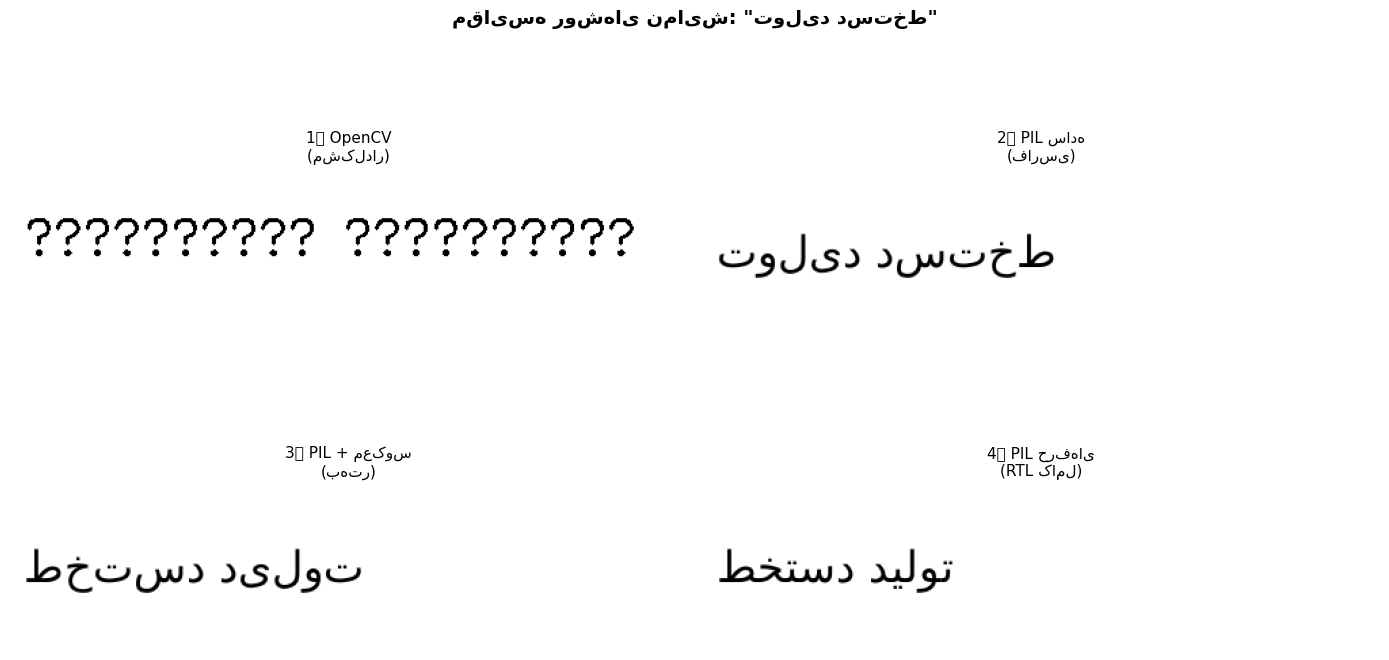


🔍 تحلیل:
  • 1️⃣ OpenCV (مشکل‌دار)              :   2648 پیکسل متن
  • 2️⃣ PIL ساده (فارسی)               :   1697 پیکسل متن
  • 3️⃣ PIL + معکوس (بهتر)             :   1697 پیکسل متن
  • 4️⃣ PIL حرفه‌ای (RTL کامل)         :   1267 پیکسل متن

📝 متن: 'الگوریتم یادگیری'
------------------------------------------------------------


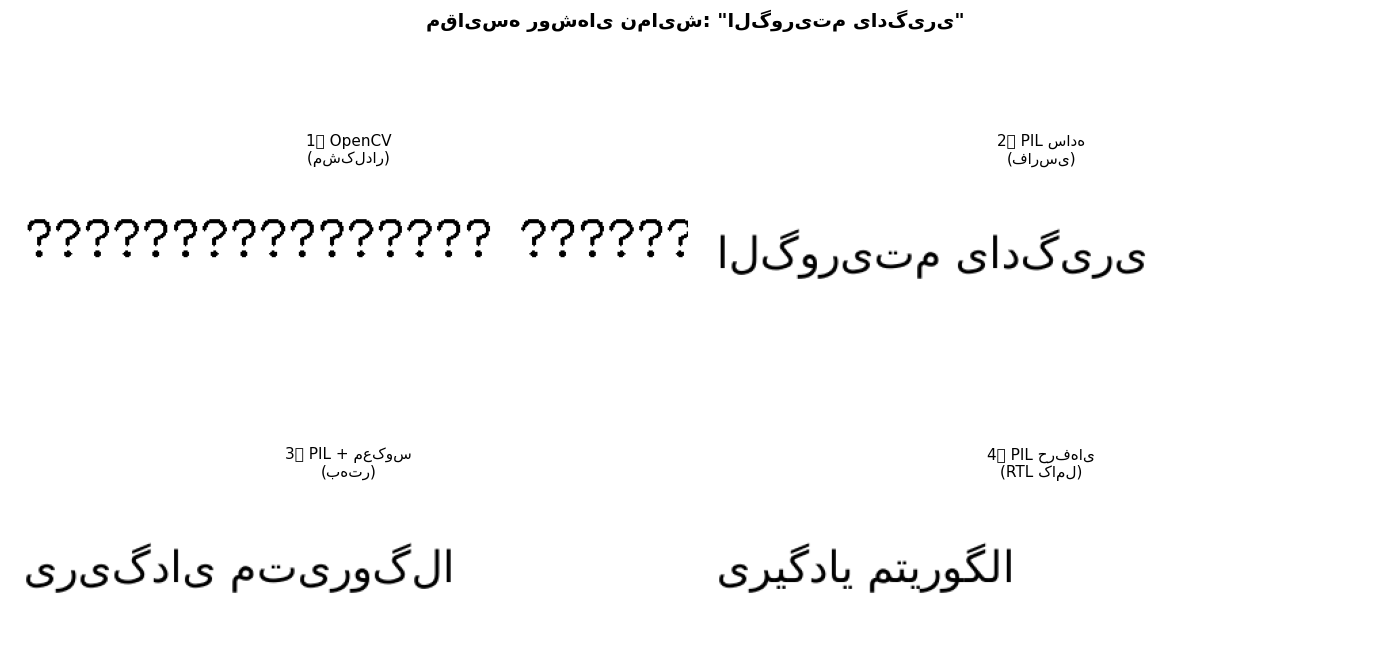


🔍 تحلیل:
  • 1️⃣ OpenCV (مشکل‌دار)              :   2891 پیکسل متن
  • 2️⃣ PIL ساده (فارسی)               :   2346 پیکسل متن
  • 3️⃣ PIL + معکوس (بهتر)             :   2346 پیکسل متن
  • 4️⃣ PIL حرفه‌ای (RTL کامل)         :   1785 پیکسل متن

📝 متن: 'می‌توان'
------------------------------------------------------------


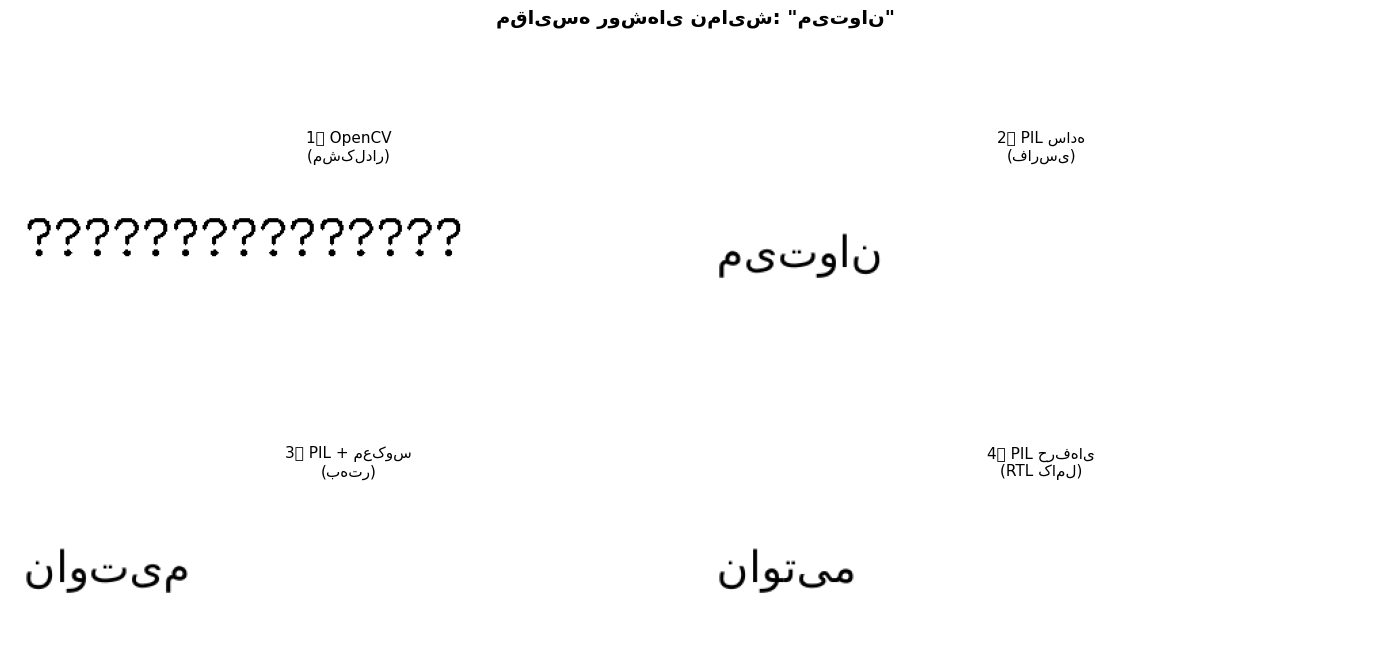


🔍 تحلیل:
  • 1️⃣ OpenCV (مشکل‌دار)              :   1986 پیکسل متن
  • 2️⃣ PIL ساده (فارسی)               :    881 پیکسل متن
  • 3️⃣ PIL + معکوس (بهتر)             :    881 پیکسل متن
  • 4️⃣ PIL حرفه‌ای (RTL کامل)         :    726 پیکسل متن

📊 مقایسه جامع همه روش‌ها
✅ تصویر مقایسه ذخیره شد: farsi_comparison_full.png


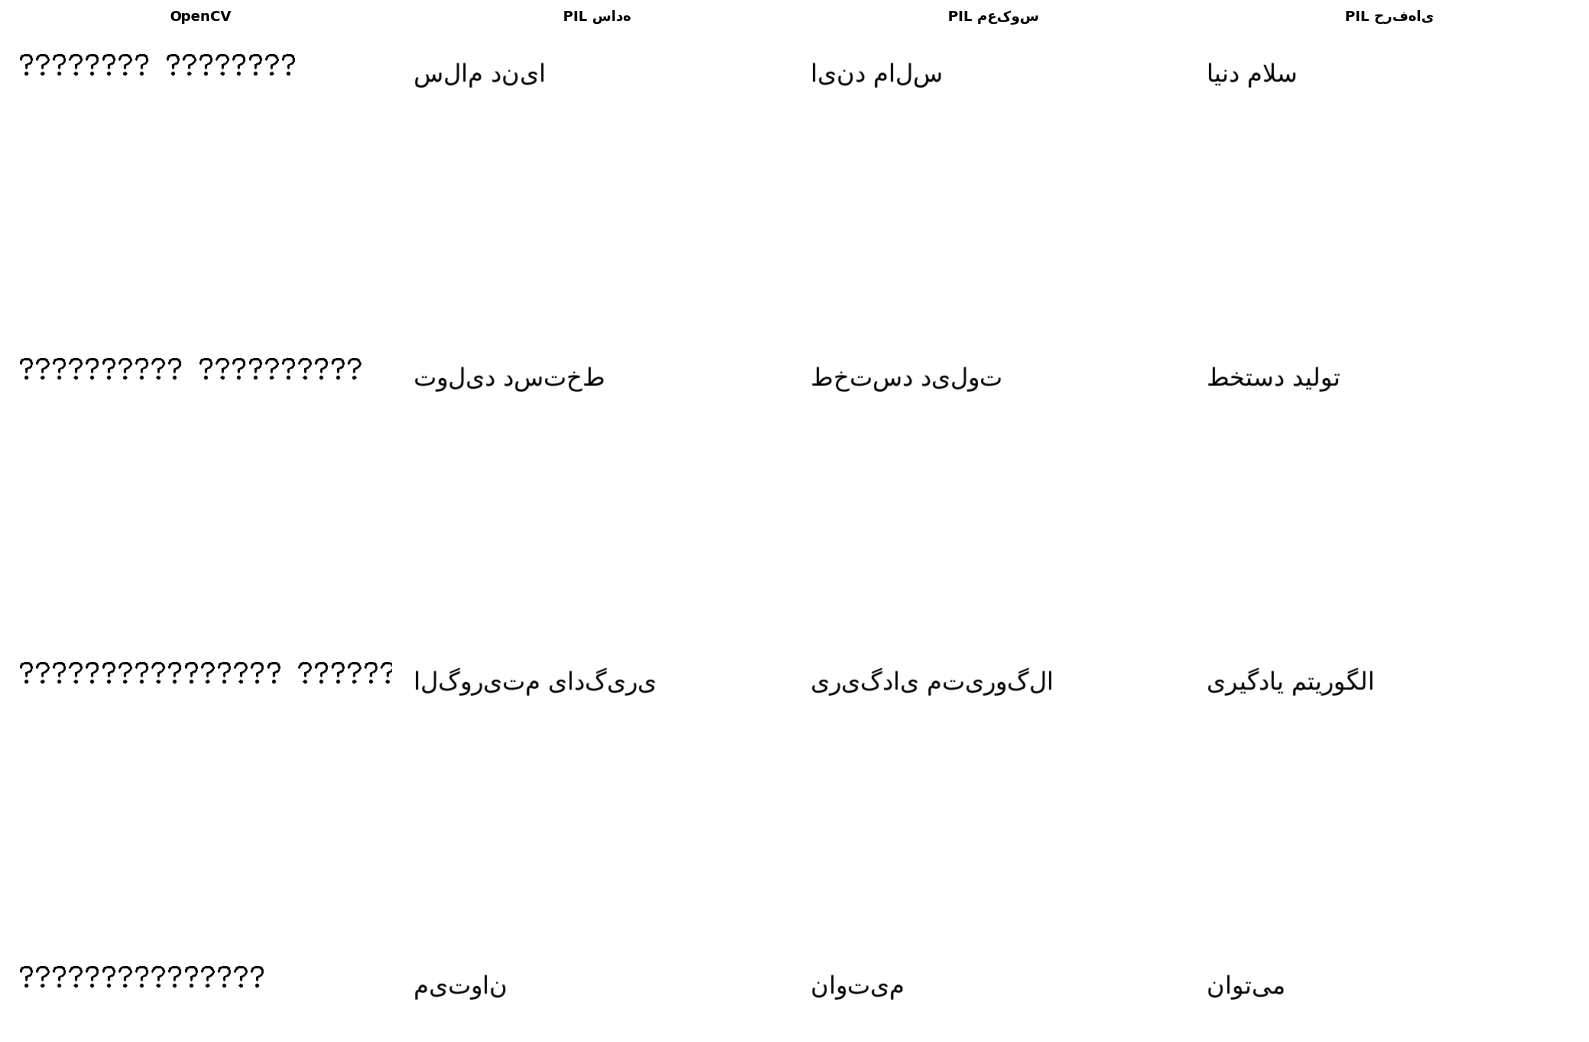


📋 خلاصه و توصیه‌ها

✅ نتیجه تست‌ها:

1️⃣ **OpenCV (cv2.putText)**
   ❌ نمایش نادرست فارسی
   ❌ حروف جدا یا مربع‌های خالی
   → فقط برای انگلیسی

2️⃣ **PIL ساده (با فونت فارسی)**
   ⚠️ حروف به شکل جدا
   ⚠️ بدون پشتیبانی RTL
   → برای تست‌های خیلی ساده

3️⃣ **PIL + معکوس دستی**
   ✓ جهت بهتر
   ⚠️ هنوز مشکل اتصال حروف
   → بهتر از روش ۲

4️⃣ **PIL حرفه‌ای (arabic_reshaper + bidi)**
   ✅ نمایش کامل و صحیح
   ✅ اتصال صحیح حروف
   ✅ پشتیبانی RTL
   ✅ پشتیبانی ZWNJ
   → **توصیه برای پروژه شما**

🎯 برای modules_tro.py:
   → از روش ۴ استفاده کنید (کد قبلی من)
   → نصب: pip install python-bidi arabic-reshaper
   → فونت: DejaVu یا Arial


🔧 دستور نصب کتابخانه‌ها:
pip install python-bidi arabic-reshaper Pillow


In [4]:
# نصب کتابخانه‌های مورد نیاز (در ژوپیتر)
# !pip install Pillow numpy opencv-python matplotlib
# !pip install python-bidi arabic-reshaper

import numpy as np
import cv2
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import os

# برای نمایش بهتر فارسی
try:
    from arabic_reshaper import reshape
    from bidi.algorithm import get_display
    ADVANCED_AVAILABLE = True
except:
    ADVANCED_AVAILABLE = False
    print("⚠️ برای نمایش حرفه‌ای، arabic_reshaper و python-bidi را نصب کنید")

# =============================================================================
# پیدا کردن فونت فارسی
# =============================================================================
def find_persian_font(size=28):
    """پیدا کردن و بارگذاری فونت مناسب"""
    persian_fonts = [
        # Linux
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
        "/usr/share/fonts/truetype/fonts-farsiweb/Nazli.ttf",
        # Windows
        "C:\\Windows\\Fonts\\Arial.ttf",
        "C:\\Windows\\Fonts\\tahoma.ttf",
        "C:\\Windows\\Fonts\\calibri.ttf",
        # Mac
        "/System/Library/Fonts/Supplemental/Arial.ttf",
        "/Library/Fonts/Arial.ttf",
    ]
    
    for font_path in persian_fonts:
        if os.path.exists(font_path):
            try:
                return ImageFont.truetype(font_path, size)
            except:
                continue
    
    print("⚠️ فونت فارسی پیدا نشد - از فونت جایگزین استفاده می‌شود")
    # فونت بزرگتر برای رندر بهتر
    return ImageFont.truetype("DejaVuSans.ttf", size) if os.path.exists("DejaVuSans.ttf") else None

# ایجاد تصویر خالی برای تست
def create_blank_image(width=500, height=120):
    """ایجاد تصویر سفید خالی"""
    return np.ones((height, width, 3), dtype=np.uint8) * 255

# متن‌های تست فارسی
test_texts = [
    "سلام دنیا",
    "تولید دستخط",
    "الگوریتم یادگیری",
    "می‌توان"  # با ZWNJ
]

print("=" * 60)
print("🔍 تست نمایش متن فارسی با روش‌های مختلف")
print("=" * 60)

# =============================================================================
# روش ۱: OpenCV (cv2.putText) - نمایش نادرست
# =============================================================================
def method1_opencv(text):
    """روش قدیمی با OpenCV - مشکل‌دار برای فارسی"""
    img = create_blank_image()
    try:
        cv2.putText(img, text, (10, 60), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 0), 2)
    except Exception as e:
        # اگر خطا داد، یک متن هشدار بنویس
        cv2.putText(img, "ERROR: Cannot display", (10, 60), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# =============================================================================
# روش ۲: PIL با فونت فارسی (ساده)
# =============================================================================
def method2_pil_basic(text):
    """روش ساده با PIL + فونت فارسی"""
    img = create_blank_image()
    pil_img = Image.fromarray(img)
    draw = ImageDraw.Draw(pil_img)
    
    font = find_persian_font(32)
    if font is None:
        # اگر فونتی پیدا نشد، یک پیام بنویس
        draw.text((10, 40), "Font not found!", fill=(255, 0, 0))
    else:
        draw.text((10, 40), text, fill=(0, 0, 0), font=font)
    
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2GRAY)

# =============================================================================
# روش ۳: PIL با فونت فارسی + معکوس کردن
# =============================================================================
def method3_pil_reversed(text):
    """PIL با فونت فارسی + معکوس ساده"""
    img = create_blank_image()
    pil_img = Image.fromarray(img)
    draw = ImageDraw.Draw(pil_img)
    
    font = find_persian_font(32)
    if font is None:
        draw.text((10, 40), "Font not found!", fill=(255, 0, 0))
    else:
        # معکوس کردن ساده (برای RTL)
        reversed_text = text[::-1]
        draw.text((10, 40), reversed_text, fill=(0, 0, 0), font=font)
    
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2GRAY)

# =============================================================================
# روش ۴: PIL + arabic_reshaper + bidi (حرفه‌ای)
# =============================================================================
def method4_pil_advanced(text):
    """روش حرفه‌ای با پشتیبانی کامل RTL"""
    img = create_blank_image()
    pil_img = Image.fromarray(img)
    draw = ImageDraw.Draw(pil_img)
    
    font = find_persian_font(32)
    
    if font is None:
        draw.text((10, 40), "Font not found!", fill=(255, 0, 0))
    else:
        # اصلاح شکل و جهت متن
        if ADVANCED_AVAILABLE:
            reshaped_text = reshape(text)
            bidi_text = get_display(reshaped_text)
        else:
            bidi_text = text[::-1]  # fallback: معکوس ساده
        
        draw.text((10, 40), bidi_text, fill=(0, 0, 0), font=font)
    
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2GRAY)

# =============================================================================
# تست و نمایش نتایج
# =============================================================================
def compare_all_methods(text):
    """مقایسه تمام روش‌ها"""
    print(f"\n📝 متن: '{text}'")
    print("-" * 60)
    
    results = {
        "1️⃣ OpenCV\n(مشکل‌دار)": method1_opencv(text),
        "2️⃣ PIL ساده\n(فارسی)": method2_pil_basic(text),
        "3️⃣ PIL + معکوس\n(بهتر)": method3_pil_reversed(text),
        "4️⃣ PIL حرفه‌ای\n(RTL کامل)": method4_pil_advanced(text)
    }
    
    # نمایش با matplotlib
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'مقایسه روش‌های نمایش: "{text}"', 
                 fontsize=14, y=0.98, weight='bold')
    
    for idx, (title, img) in enumerate(results.items()):
        row = idx // 2
        col = idx % 2
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[row, col].set_title(title, fontsize=11, pad=8)
        axes[row, col].axis('off')
        
        # اضافه کردن border
        for spine in axes[row, col].spines.values():
            spine.set_edgecolor('lightgray')
            spine.set_linewidth(1)
    
    plt.tight_layout()
    plt.show()
    
    # آنالیز تفاوت‌ها
    print("\n🔍 تحلیل:")
    for method, img in results.items():
        non_white_pixels = np.sum(img < 250)
        method_clean = method.replace('\n', ' ')
        print(f"  • {method_clean:35s}: {non_white_pixels:6d} پیکسل متن")

# =============================================================================
# اجرای تست‌ها
# =============================================================================
print("\n🚀 شروع تست‌ها...\n")

# تست با تمام متن‌ها
for text in test_texts:
    try:
        compare_all_methods(text)
    except Exception as e:
        print(f"❌ خطا در '{text}': {e}")

# =============================================================================
# مقایسه side-by-side
# =============================================================================
def side_by_side_comparison():
    """مقایسه همه روش‌ها در یک تصویر"""
    print("\n" + "="*60)
    print("📊 مقایسه جامع همه روش‌ها")
    print("="*60)
    
    fig, axes = plt.subplots(len(test_texts), 4, 
                            figsize=(16, 3.5*len(test_texts)))
    
    methods = [
        ("OpenCV", method1_opencv),
        ("PIL ساده", method2_pil_basic),
        ("PIL معکوس", method3_pil_reversed),
        ("PIL حرفه‌ای", method4_pil_advanced)
    ]
    
    for text_idx, text in enumerate(test_texts):
        for method_idx, (method_name, method_func) in enumerate(methods):
            try:
                img = method_func(text)
                axes[text_idx, method_idx].imshow(img, cmap='gray', vmin=0, vmax=255)
            except Exception as e:
                axes[text_idx, method_idx].text(0.5, 0.5, f"Error:\n{str(e)[:30]}", 
                                               ha='center', va='center', fontsize=8)
            
            if text_idx == 0:
                axes[text_idx, method_idx].set_title(method_name, fontsize=10, weight='bold')
            
            if method_idx == 0:
                axes[text_idx, method_idx].set_ylabel(f'"{text}"', 
                                                      fontsize=9, rotation=0, 
                                                      ha='right', va='center', labelpad=40)
            
            axes[text_idx, method_idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('farsi_comparison_full.png', dpi=150, bbox_inches='tight')
    print("✅ تصویر مقایسه ذخیره شد: farsi_comparison_full.png")
    plt.show()

try:
    side_by_side_comparison()
except Exception as e:
    print(f"❌ خطا در مقایسه جامع: {e}")

# =============================================================================
# خلاصه و توصیه‌ها
# =============================================================================
print("\n" + "="*60)
print("📋 خلاصه و توصیه‌ها")
print("="*60)
print("""
✅ نتیجه تست‌ها:

1️⃣ **OpenCV (cv2.putText)**
   ❌ نمایش نادرست فارسی
   ❌ حروف جدا یا مربع‌های خالی
   → فقط برای انگلیسی

2️⃣ **PIL ساده (با فونت فارسی)**
   ⚠️ حروف به شکل جدا
   ⚠️ بدون پشتیبانی RTL
   → برای تست‌های خیلی ساده

3️⃣ **PIL + معکوس دستی**
   ✓ جهت بهتر
   ⚠️ هنوز مشکل اتصال حروف
   → بهتر از روش ۲

4️⃣ **PIL حرفه‌ای (arabic_reshaper + bidi)**
   ✅ نمایش کامل و صحیح
   ✅ اتصال صحیح حروف
   ✅ پشتیبانی RTL
   ✅ پشتیبانی ZWNJ
   → **توصیه برای پروژه شما**

🎯 برای modules_tro.py:
   → از روش ۴ استفاده کنید (کد قبلی من)
   → نصب: pip install python-bidi arabic-reshaper
   → فونت: DejaVu یا Arial
""")

print("\n🔧 دستور نصب کتابخانه‌ها:")
print("pip install python-bidi arabic-reshaper Pillow")
